<a href="https://colab.research.google.com/github/Ziad-Gebril/KNN/blob/K_Nearest_Users/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ratings = pd.read_csv("/content/drive/MyDrive/KNN/ml-latest-small/ratings.csv")
movies = pd.read_csv("/content/drive/MyDrive/KNN/ml-latest-small/movies.csv")

In [4]:
num_users = ratings["userId"].nunique()
num_movies = movies["movieId"].nunique()
num_ratings = len(ratings)
sparsity = 1 - num_ratings/(num_users*num_movies)

In [5]:
print(f"Number of unique users: {num_users}")
print(f"Number of unique movies: {num_movies}")
print(f"Number of total ratings: {num_ratings}")
print(f"Matrix Sparsity: {sparsity:.4f} ({sparsity *100:.2f}%)")

Number of unique users: 610
Number of unique movies: 9742
Number of total ratings: 100836
Matrix Sparsity: 0.9830 (98.30%)


In [6]:
user_item_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

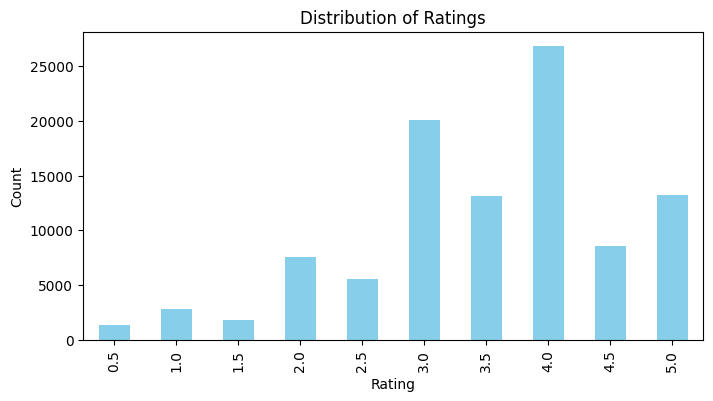

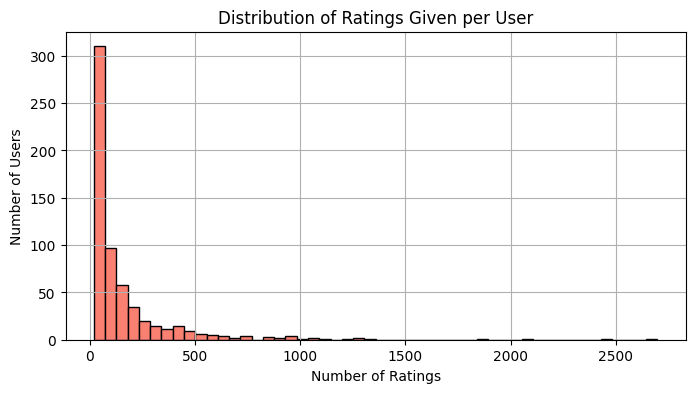

In [7]:
#helped by ai for syntax

plt.figure(figsize=(8, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

user_rating_counts = ratings.groupby('userId').size()
plt.figure(figsize=(8, 4))
user_rating_counts.hist(bins=50, color='salmon', edgecolor='black')
plt.title('Distribution of Ratings Given per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.show()

In [8]:
def get_co_rated(matrix, a, b, axis):
    if axis == "index":
        vec_a = matrix.loc[a]
        vec_b = matrix.loc[b]

    elif axis == "columns":
        vec_a = matrix[a]
        vec_b = matrix[b]

    else:
        raise ValueError("axis must be 'index' or 'columns'")

    mask = vec_a.notna() & vec_b.notna()

    return vec_a[mask].to_numpy(),vec_b[mask].to_numpy()

In [9]:
vector_a, vector_b = get_co_rated(user_item_matrix, 1, 5,"index")

print("Vector A (User 1 ratings for co-rated items):", vector_a)
print("Vector B (User 5 ratings for co-rated items):", vector_b)
A = np.array([5, 4, 5, 3])
B = np.array([3, 2, 3, 1])

Vector A (User 1 ratings for co-rated items): [4. 5. 4. 3. 3. 4. 4. 5. 5. 4. 4. 5. 5.]
Vector B (User 5 ratings for co-rated items): [4. 4. 4. 5. 2. 3. 4. 4. 5. 5. 3. 5. 3.]


In [10]:
def euclidean_similarity(A, B):
    distance = np.sqrt(np.sum((np.array(A) - np.array(B)) ** 2))
    print(distance)
    similarity = 1 / (1 + distance)
    return similarity

In [11]:
EuclideanSimilarity=euclidean_similarity(vector_a, vector_b)
print(EuclideanSimilarity)

3.7416573867739413
0.21089672205953397


In [12]:
def cosine_similarity(A, B):
    A = np.array(A)
    B = np.array(B)

    numerator = np.dot(A, B)
    denominator = np.sqrt(np.sum(A**2)) * np.sqrt(np.sum(B**2))

    if denominator == 0:
        return 0

    return numerator / denominator

In [13]:
CosineSimilarity=cosine_similarity(vector_a, vector_b)
print(CosineSimilarity)

0.9707699301444195


In [14]:
def pearson_similarity(A, B):
    A = np.array(A)
    B = np.array(B)

    A_centered = A - np.mean(A)
    B_centered = B - np.mean(B)

    numerator = np.dot(A_centered, B_centered)
    denominator = np.sqrt(np.sum(A_centered**2)) * np.sqrt(np.sum(B_centered**2))

    if denominator == 0:
        return 0

    return numerator / denominator

In [15]:
PearsonSimilarity=pearson_similarity(vector_a, vector_b)
print(PearsonSimilarity)

0.2687490263457713


In [16]:
def find_k_nearest_users(matrix, target_user, k, similarity_fn):
    similarities = []

    for user in matrix.index:
        if user == target_user:
            continue

        vec1, vec2 = get_co_rated(matrix, target_user, user, axis="index")

        if len(vec1) < 2:
            continue

        score = similarity_fn(vec1, vec2)
        similarities.append((user, score))

    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:k]

In [24]:
def predict_rating_user_based(matrix, target_user, target_item, k, similarity_fn):
    neighbors = find_k_nearest_users(matrix, target_user, k, similarity_fn)

    weighted_sum = 0
    similarity_sum = 0

    for neighbor_id, similarity in neighbors:
        rating = matrix.loc[neighbor_id, target_item]

        if pd.notna(rating):
            weighted_sum += similarity * rating
            similarity_sum += abs(similarity)

    if similarity_sum == 0:
        return None

    return weighted_sum / similarity_sum

In [25]:
def find_k_nearest_items(matrix, target_item, k, similarity_fn):
    similarities = []

    for item in matrix.columns:
        if item == target_item:
            continue

        vec1, vec2 = get_co_rated(matrix, target_item, item, axis="columns")

        if len(vec1) < 2:
            continue

        score = similarity_fn(vec1, vec2)
        similarities.append((item, score))

    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:k]

In [26]:
def predict_rating_item_based(matrix, target_user, target_item, k, similarity_fn):
    neighbors = find_k_nearest_items(matrix, target_item, k, similarity_fn)

    weighted_sum = 0
    similarity_sum = 0

    for item_id, similarity in neighbors:
        rating = matrix.loc[target_user, item_id]

        if pd.notna(rating):
            weighted_sum += similarity * rating
            similarity_sum += abs(similarity)

    if similarity_sum == 0:
        return None

    return weighted_sum / similarity_sum

We used the same logic for part d as part c we only changed the lines    "matrix.index" to "matrix.columns" and "axis="index" to "axis="columns" to find the nearest movies instead of nearest users

In [27]:
def train_test_split_ratings(ratings_df, test_fraction=0.2):
    train_parts = []
    test_parts = []

    for user_id, group in ratings_df.groupby("userId"):
        group = group.sample(frac=1, random_state=42)

        test_size = int(len(group) * test_fraction)

        if test_size == 0 and len(group) > 1:
            test_size = 1

        test_parts.append(group.iloc[:test_size])
        train_parts.append(group.iloc[test_size:])

    train_df = pd.concat(train_parts)
    test_df = pd.concat(test_parts)

    return train_df, test_df